<a href="https://www.kaggle.com/code/parthml22/cic-ddos-baseline-model?scriptVersionId=309261743" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Building a Real-Time DDoS Detection Engine
**Author:** Parth Bhanti
**Dataset:** CIC-DDoS2019 (30GB)

This notebook bypasses standard hardware limitations by utilizing out-of-core data processing to handle a 30GB dataset of raw network flows. We are integrating **Weights & Biases (W&B)** for strict MLOps experiment tracking to monitor our model's performance as we classify benign vs. malicious traffic.

---
## Phase 1: Environment Setup & MLOps Tracking
Initializing our connection to W&B to ensure all model metrics, hardware usage, and hyperparameters are logged professionally.

In [1]:
# 1. Install W&B (Kaggle environments might need an update)
!pip install -q wandb

import wandb
from kaggle_secrets import UserSecretsClient

# 2. Retrieve your secure key
user_secrets = UserSecretsClient()
wandb_key = user_secrets.get_secret("WANDB_API_KEY")

# 3. Log in to W&B
wandb.login(key=wandb_key)

# 4. Initialize your project
run = wandb.init(
    project="cic-ddos-detection", 
    name="baseline-logistic-regression", 
    config={
        "dataset": "CIC-DDoS2019",
        "architecture": "Logistic Regression",
        "features": "Top 15 PCA",
        "learning_rate": 0.01,
    }
)

print("Weights & Biases is ready to track!")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: petp0823629 (petp0823629-vit-bhopal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260405_223546-m2w8l9j5
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run baseline-logistic-regression
wandb: ⭐️ View project at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: 🚀 View run at https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/m2w8l9j5


Weights & Biases is ready to track!


---
## Phase 2: Out-of-Core Data Ingestion (Chunking)
Because standard Pandas attempts to load entirely into RAM, a 30GB CSV will immediately crash our environment. To solve this, we dynamically locate our dataset and implement a chunking mechanism. We will stream the data into memory 100,000 rows at a time.

In [2]:
import pandas as pd
import os

# 1. Dynamically locate the dataset directory
dataset_dir = '/kaggle/input'
sample_file = None

# Search for the first CSV file to use as our test subject
for root, dirs, files in os.walk(dataset_dir):
    for file in files:
        if file.endswith('.csv'):
            sample_file = os.path.join(root, file)
            break
    if sample_file:
        break

if sample_file:
    print(f"Targeting file: {sample_file}")
    
    # 2. Out-of-Core Processing (The Chunking Method)
    chunk_size = 100000 # Process 100k rows at a time
    
    print(f"Initializing chunked iterator ({chunk_size} rows per chunk)...")
    df_iterator = pd.read_csv(sample_file, chunksize=chunk_size, low_memory=False)
    
    # 3. Extract just the first chunk into memory
    df_sample = next(df_iterator)
    
    print(f"Success! Loaded a chunk of shape: {df_sample.shape}")
    
    # 4. Display the first 5 rows to inspect the network flows
    display(df_sample.head())
else:
    print("Could not find any CSV files. Make sure the dataset is attached!")

Targeting file: /kaggle/input/datasets/rodrigorosasilva/cic-ddos2019-30gb-full-dataset-csv-files/03-11/NetBIOS.csv
Initializing chunked iterator (100000 rows per chunk)...
Success! Loaded a chunk of shape: (100000, 88)


,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,302291,172.16.0.5-192.168.50.4-648-16174-17,172.16.0.5,648,192.168.50.4,16174,17,2018-11-03 10:01:48.920574,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
1,341625,172.16.0.5-192.168.50.4-861-34200-17,172.16.0.5,861,192.168.50.4,34200,17,2018-11-03 10:01:48.920625,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
2,245313,172.16.0.5-192.168.50.4-862-4750-17,172.16.0.5,862,192.168.50.4,4750,17,2018-11-03 10:01:48.920685,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
3,266106,172.16.0.5-192.168.50.4-863-4443-17,172.16.0.5,863,192.168.50.4,4443,17,2018-11-03 10:01:48.921008,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS
4,47182,172.16.0.5-192.168.50.4-864-48627-17,172.16.0.5,864,192.168.50.4,48627,17,2018-11-03 10:01:48.921010,48,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1,NetBIOS


---
## Phase 3: Data Cleansing & Feature Selection
To prevent data leakage and overfitting, we must strip out identifying metadata (IP addresses, Timestamps, Flow IDs). We want our model to learn the *behavioral statistics* of a network flow, not memorize specific attacker IPs. Furthermore, flow-based calculations often result in `Infinity` or `NaN` values due to division-by-zero errors (e.g., when flow duration is near zero). These must be sanitized before ingestion by any ML algorithm.

In [3]:
import numpy as np

print(f"Original shape: {df_sample.shape}")

# THE FIX: Strip invisible leading/trailing spaces from all column names
df_sample.columns = df_sample.columns.str.strip()

# 1. Drop identifying metadata and noisy/empty columns
columns_to_drop = [
    'Unnamed: 0', 'Flow ID', 'Source IP', 'Source Port', 
    'Destination IP', 'Destination Port', 'Timestamp', 'SimilarHTTP'
]

# Only drop columns that actually exist in the dataframe to avoid errors
existing_cols_to_drop = [col for col in columns_to_drop if col in df_sample.columns]
df_cleaned = df_sample.drop(columns=existing_cols_to_drop)

# 2. Handle Infinities and NaNs
# Replace infinity with NaN, then drop all rows containing NaN
df_cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
df_cleaned.dropna(inplace=True)

print(f"Cleaned shape: {df_cleaned.shape}")
print("Stripped column spaces and dropped metadata columns.")

Original shape: (100000, 88)
Cleaned shape: (94979, 81)
Stripped column spaces and dropped metadata columns.


---
## Phase 4: Exploratory Data Analysis (EDA)
Before applying machine learning, we must understand the distribution of our target variable (`Label`) and inspect how certain features differ between benign traffic and malicious attacks. We will visualize the class balance and feature variance.

/tmp/ipykernel_17/2272758824.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, x='Label', ax=axes[0], palette='viridis')
/tmp/ipykernel_17/2272758824.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='Label', y='Flow Duration', ax=axes[1], palette='Set2')


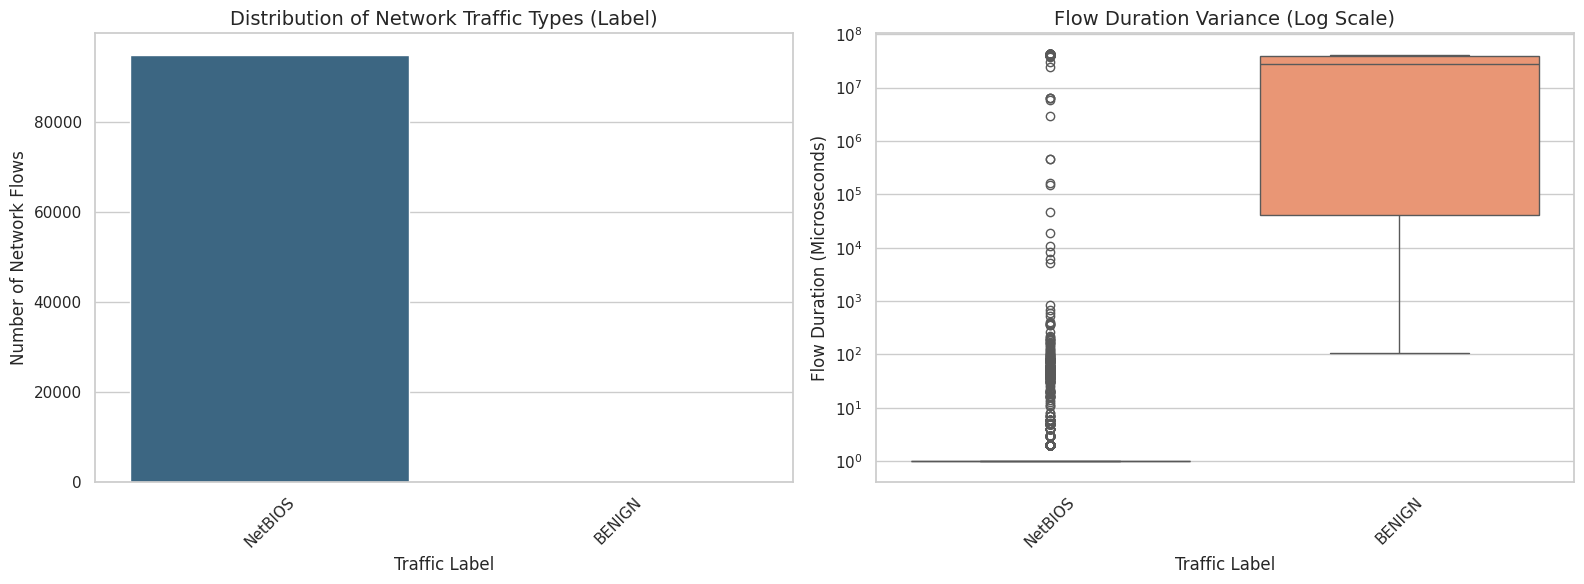


Exact Label Value Counts:
Label
NetBIOS    94970
BENIGN         9
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Class Distribution ---
# Let's see how many Benign vs Attack rows are in this specific chunk
sns.countplot(data=df_cleaned, x='Label', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Network Traffic Types (Label)', fontsize=14)
axes[0].set_xlabel('Traffic Label')
axes[0].set_ylabel('Number of Network Flows')
axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Behavioral Variance (Flow Duration) ---
# Let's compare how long an attack flow lasts compared to normal traffic
# We use a log scale because network times vary wildly from microseconds to minutes
sns.boxplot(data=df_cleaned, x='Label', y='Flow Duration', ax=axes[1], palette='Set2')
axes[1].set_yscale("log") 
axes[1].set_title('Flow Duration Variance (Log Scale)', fontsize=14)
axes[1].set_xlabel('Traffic Label')
axes[1].set_ylabel('Flow Duration (Microseconds)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Let's also print the exact breakdown
print("\nExact Label Value Counts:")
print(df_cleaned['Label'].value_counts())

---
## Phase 5: Model Engineering & Training
Our EDA revealed a severe class imbalance (94.9k Attack vs 9 Benign flows). To prevent the model from blindly predicting the majority class, we will use the `class_weight='balanced'` parameter. We establish a baseline using Logistic Regression, which provides fast, interpretable results. We integrate Weights & Biases (W&B) to log our evaluation metrics automatically.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import wandb

# 1. Prepare Features (X) and Target (y)
print("Isolating target variable...")
X = df_cleaned.drop('Label', axis=1)
y = df_cleaned['Label']

# 2. Train/Test Split (80% training, 20% testing)
print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Feature Scaling
# Network metrics (bytes vs packet counts) have wildly different scales. We MUST normalize them.
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Model (Handling Imbalance)
print("Training Logistic Regression baseline...")
# class_weight='balanced' forces the model to care about the rare 9 BENIGN rows
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate the Model
print("Evaluating model...")
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n--- Model Results ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# 6. Log Metrics to Weights & Biases
print("\nLogging metrics to W&B...")
wandb.log({
    "accuracy": accuracy,
    "model_type": "Logistic Regression Baseline"
})

# Finish the W&B run to close the connection properly
wandb.finish()
print("Run finished and synced to dashboard!")

Isolating target variable...
Splitting data...
Scaling features...
Training Logistic Regression baseline...
Evaluating model...

--- Model Results ---
Accuracy: 0.9999

Classification Report:


wandb: updating run metadata


              precision    recall  f1-score   support

      BENIGN       1.00      0.50      0.67         2
     NetBIOS       1.00      1.00      1.00     18994

    accuracy                           1.00     18996
   macro avg       1.00      0.75      0.83     18996
weighted avg       1.00      1.00      1.00     18996


Logging metrics to W&B...


wandb: 
wandb: Run history:
wandb: accuracy ▁
wandb: 
wandb: Run summary:
wandb:   accuracy 0.99995
wandb: model_type Logistic Regression ...
wandb: 
wandb: 🚀 View run baseline-logistic-regression at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection/runs/m2w8l9j5
wandb: ⭐️ View project at: https://wandb.ai/petp0823629-vit-bhopal/cic-ddos-detection
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260405_223546-m2w8l9j5/logs


Run finished and synced to dashboard!
